# Storm tracking
This notebook is for running the storm tracking algorithm and creating the diagnostics plots to observe the general and individual results. For running the results you need the storm catalog output from the RaindyDay, the shapefiles of the transposition domain and control area, and the following packages.


In [1]:
#Packages:
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.patches import Ellipse # draw ellipse on figures
import numpy as np
from pyproj import Transformer # convert lat/lon to projected coordinates
from geographiclib.geodesic import Geodesic # compute storm centroid movement
import geopandas as gpd # read shapefiles
import os
import pandas as pd
import scrapbook as sb
import sys 

### Storm tracking packages
The following packages need to be in the same folder as this notebook

In [2]:
from pathlib import Path


# add project root (parent of Notebooks/) to sys.path
root = Path.cwd().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))



# Import storm dataset and related modules
from functions.storm_dataset import storm_tracking_event, continuos_storm, storm_tracking_features
from functions.storm_direction import mean_precipitation_within_ellipse, get_max_accumulated_value, compute_line_length, mean_velocity, mean_direction, mean_direction_ln
from functions.diagnostic_plots import diagnostic_plot_storm_trajectories, plot_storm_track, plot_storm_time_steps

### Storm tracking parameters
Define the parameter for the storm tracking run and analysis


In [3]:
## Storm tracking parameters
morph_radius = 4 # radius for morph structure
high_treshold = 0.2 # threshold for high precipitation (in mm/hr)
storm_interval = '12H' # storm time interval for getting the most intese precipitation

## Reading control area and transposition domain shapefile
control_area_path = '/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/RainyDay_Runs/Run_CONUS/Shapes/control_area_circle_3.0.shp'
transposition_domain_path = "/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Projects/Cartography/Domain_IOWA.shp"

# Read the storm catalog
#folder = run_folder +  '/Results/'+ scenario_name+'/StormCatalog/'
catalog_folder  = '/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/RainyDay_Runs/Run_CONUS/Results/Domain_3.0_circle_10000km2/StormCatalog'

## Set the path for the output folder and figure path
fig_path ='/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Paper_Notebooks/CONUS_storm_tracking'

In [4]:
# Parameters
morph_radius = 4
high_treshold = 0.2
storm_interval = "12H"
control_area_path = "/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Projects/Cartography/wsh_05488110.shp"
transposition_domain_path = "/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Projects/Cartography/IOWA_D_wgs.shp"
catalog_folder = "/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/RainyDay_Runs/IOWA_Run/Results/IOWA_Watershed_Domain/StormCatalog"


### Reading storm catalog name files

In [5]:
control_area = gpd.read_file(control_area_path)
transposition_domain = gpd.read_file(transposition_domain_path)
# Get the list of storm events from the catalog folder

event_list = os.listdir(catalog_folder)
event_list = [event for event in event_list if event.endswith('.nc')] ## filter only netcdf files

### Creating folder for saving plots

In [6]:

#create folders for saving plots
storm_track_path = os.path.join(fig_path, 'StormTrack')
if not os.path.exists(storm_track_path):
    os.makedirs(storm_track_path)
storm_time_timesteps_path = os.path.join(fig_path, 'StormTimeSteps')
if not os.path.exists(storm_time_timesteps_path):
    os.makedirs(storm_time_timesteps_path)

### Running the storm tracking algorithm

In [7]:
# create dictionary to store the results
storm_tracking_results = {}

# Iterate over each event in the event_list
event_list.sort()

for event in event_list:
    # Initialize an empty dictionary for each event
    storm_tracking_results[event] = {}

for storm_event in event_list:
    ds = xr.open_dataset(os.path.join(catalog_folder, storm_event)) # Load the dataset
    print(storm_event)
    event_dict = {}
    storm_tracking_event(ds, event_dict, morph_radius=morph_radius, high_threshold=high_treshold)
    continuos_storm(event_dict)
    storm_tracking_features(event_dict)
    storm_tracking_results[storm_event] = event_dict # Store the results in the dictionary

IOWA_Domain.nc_storm_100_20181129.nc


The longest storm has a valid duration of 42 hours
The selected duration is longer than 0.1 of 72 hours
Selected storm starts from 2018-12-01T00:00:00.000000000 to 2018-12-02T17:00:00.000000000
Selected storm duration 42 hours
IOWA_Domain.nc_storm_101_20201123.nc


The longest storm has a valid duration of 46 hours
The selected duration is longer than 0.1 of 72 hours
Selected storm starts from 2020-11-23T19:00:00.000000000 to 2020-11-25T20:00:00.000000000
Selected storm duration 50 hours
IOWA_Domain.nc_storm_102_20061229.nc


The longest storm has a valid duration of 41 hours
The selected duration is longer than 0.1 of 72 hours
Selected storm starts from 2006-12-30T09:00:00.000000000 to 2007-01-01T01:00:00.000000000
Selected storm duration 41 hours
IOWA_Domain.nc_storm_103_20120620.nc


The longest storm has a valid duration of 13 hours
The selected duration is longer than 0.1 of 72 hours
Selected storm starts from 2012-06-20T21:00:00.000000000 to 2012-06-21T09:00:00.000000000
Selected storm duration 13 hours
IOWA_Domain.nc_storm_104_20220721.nc


...

The longest storm has a valid duration of 20 hours
The selected duration is longer than 0.1 of 72 hours
Selected storm starts from 2019-03-14T04:00:00.000000000 to 2019-03-14T23:00:00.000000000
Selected storm duration 20 hours
IOWA_Domain.nc_storm_97_20060826.nc


The longest storm has a valid duration of 23 hours
The selected duration is longer than 0.1 of 72 hours
Selected storm starts from 2006-08-28T01:00:00.000000000 to 2006-08-28T23:00:00.000000000
Selected storm duration 23 hours
IOWA_Domain.nc_storm_98_20180219.nc


The longest storm has a valid duration of 38 hours
The selected duration is longer than 0.1 of 72 hours
Selected storm starts from 2018-02-19T10:00:00.000000000 to 2018-02-20T23:00:00.000000000
Selected storm duration 38 hours
IOWA_Domain.nc_storm_99_20151126.nc


The longest storm has a valid duration of 23 hours
The selected duration is longer than 0.1 of 72 hours
Selected storm starts from 2015-11-26T12:00:00.000000000 to 2015-11-27T10:00:00.000000000
Selected storm duration 23 hours
IOWA_Domain.nc_storm_9_20090722.nc


The longest storm has a valid duration of 10 hours
The selected duration is longer than 0.1 of 72 hours
Selected storm starts from 2009-07-24T15:00:00.000000000 to 2009-07-25T03:00:00.000000000
Selected storm duration 13 hours


### Computing storm's speed and direction

In [8]:
# list for storing the results
storm_mean_velocity = []
storm_mean_direction_vector = []
storm_mean_direction_lm = []
position=[]

# dictory to store the trajectories in the defined time window
storm_trajectories = {}
# Iterate over each storm event in the tracking results
for storm_event in storm_tracking_results.keys():
    storm = storm_tracking_results[storm_event]
    mean_p_ellipse = mean_precipitation_within_ellipse(storm)
    mean_p = pd.Series(mean_p_ellipse, index=storm['selected_storm_time_steps'].values)
    most_intense_interval = get_max_accumulated_value(mean_p, storm_interval)
    start_time_index = most_intense_interval[3] # start time index 
    end_time_index = most_intense_interval[4] # end time index
    
    # Getting the centroid coordinates for the start and end time
    x = storm['storm_prj_lon_cent_list'][start_time_index:end_time_index]
    y = storm['storm_prj_lat_cent_list'][start_time_index:end_time_index]

    # compute the length of the trajectory
    trajectory_length = compute_line_length(x, y)

    storm_trajectories[storm_event] = {
        'start_time_index': start_time_index,
        'end_time_index': end_time_index,
        'x_coords': x,
        'y_coords': y,
        'trajectory_length': trajectory_length,
        'mean_precipitation': mean_p_ellipse[start_time_index:end_time_index+1].mean(),
        'storm_id': int(storm_event.split('_storm_')[1].split('_')[0]),  # Extracting storm ID from the filename 
    }
    
    # Compute the mean velocity and direction
    v = mean_velocity(x, y)
    d,vd = mean_direction(x, y)
    lm = mean_direction_ln(x, y)[0]
    # Append the results to the lists
    storm_mean_velocity.append(v)
    storm_mean_direction_vector.append(d)
    storm_mean_direction_lm.append(lm)
    position.append(storm_event[-20:-12]) # storm ID
    # Saving the results for each storm
    storm_tracking_results[storm_event]['mean_velocity'] = v
    storm_tracking_results[storm_event]['mean_direction'] = d
    storm_tracking_results[storm_event]['var_direction'] = vd
    storm_tracking_results[storm_event]['mean_direction_ln'] = lm
    # Define the transformer for converting projected coordinates to geographic coordinates
transformer = Transformer.from_crs("EPSG:2163", "EPSG:4326", always_xy=True)

# Create a dictionary to store the geographic trajectories
geographic_trajectories = {}

# Iterate over each trajectory in storm_trajectories
for storm_event, traj in storm_trajectories.items():
    x_coords = traj['x_coords']
    y_coords = traj['y_coords']
    
    # Transform the coordinates
    lon_coords, lat_coords = transformer.transform(x_coords, y_coords)
    
    # Store the geographic coordinates in the dictionary
    geographic_trajectories[storm_event] = {
        'start_time_index': traj['start_time_index'],
        'end_time_index': traj['end_time_index'],
        'lon_coords': lon_coords,
        'lat_coords': lat_coords,
        'trajectory_length': traj['trajectory_length']
    }

df = pd.DataFrame.from_dict(storm_trajectories,orient='index')

/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer/functions/storm_direction.py:145: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  window = pd.to_timedelta(window)
/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer/functions/storm_direction.py:117: RuntimeWarning: Mean of empty slice.
  m = selected_storm[t][ellipse_mask].mean()
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


In [9]:
storm['selected_storm'][2:5] # Check the keys of the storm dictionary

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]],
      shape=(3, 145, 195), dtype=float32)

### Creationg diagnostic plots 

/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


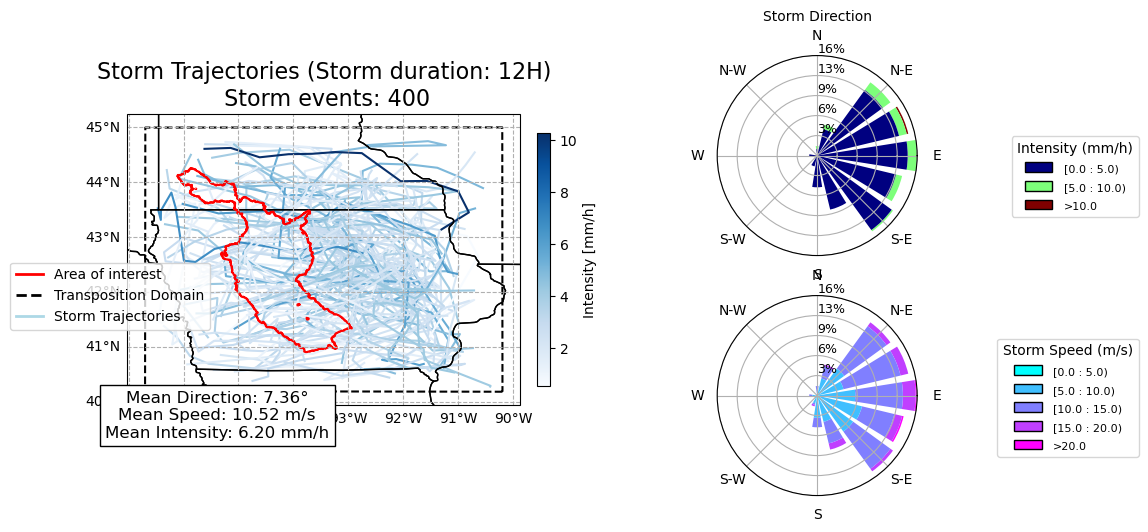

/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


In [10]:
# Create a folder for the diagnostic plots
#diagnostic_plots_folder = os.path.join(scenario_folder, 'Diagnostic_Plots')
longest_trajectories = dict(sorted(storm_trajectories.items(), key=lambda item: item[1]['trajectory_length'], reverse=True)[:100])
mean_angle = np.degrees(np.arctan2(np.mean(np.sin(np.radians(storm_mean_direction_vector))), 
                                       np.mean(np.cos(np.radians(storm_mean_direction_vector))))) # mean angle of the storm trajectories
sb.glue('mean_angle', float(mean_angle)) # record the mean angle using papermill
mean_vel = np.mean(storm_mean_velocity) # mean velocity of the storm trajectories
sb.glue('mean_vel', float(mean_vel)) # record the mean velocity using papermill
mean_p = np.mean(mean_p_ellipse)
sb.glue('mean_p', float(mean_p)) # record the mean precipitation using papermill



diagnostic_plot_storm_trajectories(
    df = df, longest_trajectories= longest_trajectories, 
    geographic_trajectories =geographic_trajectories, 
    wsh = control_area, 
    transposition_domain = transposition_domain,
    storm_mean_direction_vector = storm_mean_direction_vector, 
    storm_mean_velocity = storm_mean_velocity, 
    mean_angle = mean_angle, mean_vel = mean_vel, 
    mean_p_ellipse = mean_p, 
    time_window =  storm_interval,
    save_path = fig_path)

# Save the storm tracking results to a CSV file
tracking_results_df = pd.DataFrame.from_dict(storm_tracking_results, orient='index')
#tracking_results_df.to_csv(os.path.join(folder, 'storm_tracking_results.csv'))

In [11]:
x =  [1,2,3,4,5] # list to store the x coordinates of the storm centroids
y = [6,7,8,9,0] # list to store the y coordinates of the storm centroids
zipped_coords = zip(x, y)

In [12]:
for i,j in zipped_coords:
    print(f"Coordinates: ({i}, {j})")

Coordinates: (1, 6)
Coordinates: (2, 7)
Coordinates: (3, 8)
Coordinates: (4, 9)
Coordinates: (5, 0)


In [13]:
# Plot storm trajectories and time steps


for storm_track in storm_tracking_results.keys():
    plot_storm_track(
        storm_tracking_results=storm_tracking_results, 
        storm_name= storm_track, 
        storm_trajectories=storm_trajectories,
        save_path=storm_track_path)
    
    st = storm_trajectories[storm_track]['start_time_index']
    en = storm_trajectories[storm_track]['end_time_index']
    plot_storm_time_steps(storm_tracking_results=storm_tracking_results,
                          storm_name=storm_track, start_end= (st,en),
                          time_window=storm_interval,
                          save_path=storm_time_timesteps_path)

/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely

/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely

...

/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


KeyboardInterrupt: 

/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
